# Sales Forecasting — Baseline
**Goal:** Predict daily `Revenue` and `COGS` for 2023-01-01 → 2024-07-01 using historical data (2012–2022).

**Strategy (simple seasonal average + trend):**
1. Compute average YoY growth rate from 2013–2022.
2. Build a "seasonal profile" — the average Revenue/COGS for each calendar day-of-year across all historical years.
3. Scale the profile by the projected year-level trend to produce predictions.

## 1 — Imports & Config

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

DATA_DIR  = '../data/raw/'
TRAIN_FILE = DATA_DIR + 'sales.csv'
TEST_FILE  = DATA_DIR + 'sample_submission.csv'
OUT_FILE   = DATA_DIR + 'submission.csv'

## 2 — Load & Inspect Data

In [5]:
train = pd.read_csv(TRAIN_FILE, parse_dates=['Date'])
test  = pd.read_csv(TEST_FILE,  parse_dates=['Date'])

print('Train shape:', train.shape)
print('Train date range:', train['Date'].min().date(), '→', train['Date'].max().date())
print()
print('Test shape:', test.shape)
print('Test date range:', test['Date'].min().date(), '→', test['Date'].max().date())
print()
train.tail()

Train shape: (3833, 3)
Train date range: 2012-07-04 → 2022-12-31

Test shape: (548, 3)
Test date range: 2023-01-01 → 2024-07-01



,Date,Revenue,COGS
3828,2022-12-27,2100553.66,2184872.24
3829,2022-12-28,3448729.20,3513621.00
3830,2022-12-29,3083944.33,3170787.10
3831,2022-12-30,2884668.76,3022292.15
3832,2022-12-31,2383037.48,2279288.13


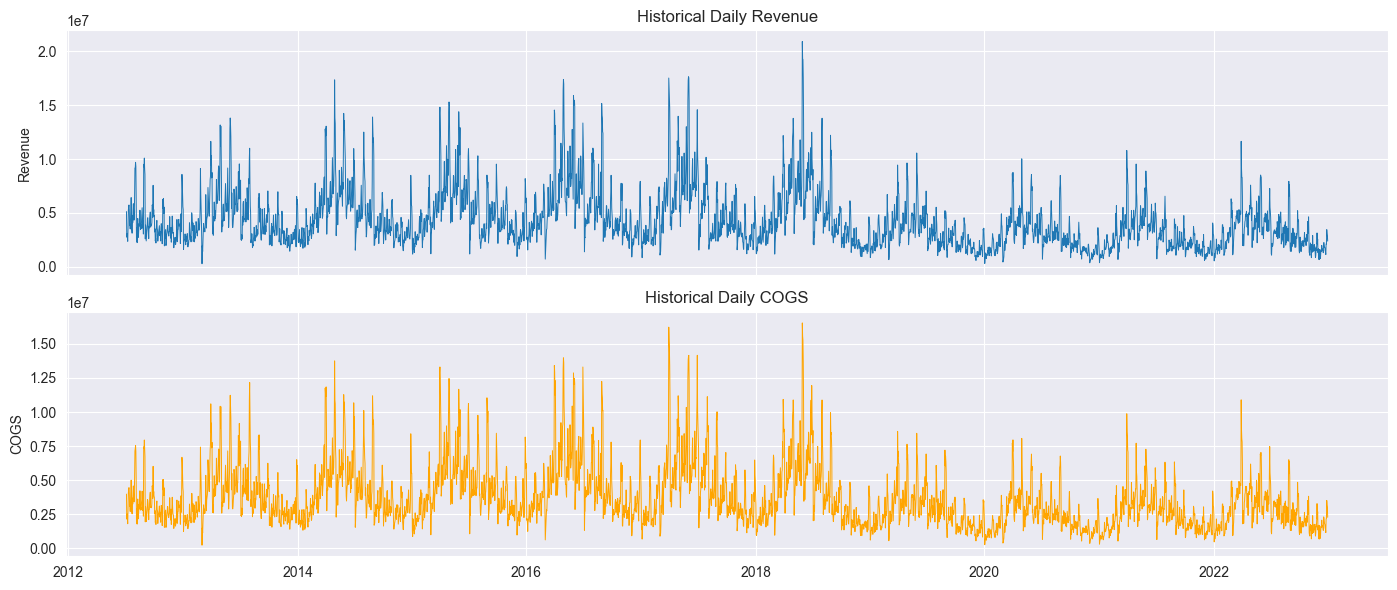

In [6]:
fig, axes = plt.subplots(2, 1, figsize=(14, 6), sharex=True)
axes[0].plot(train['Date'], train['Revenue'], lw=0.7)
axes[0].set_title('Historical Daily Revenue'); axes[0].set_ylabel('Revenue')
axes[1].plot(train['Date'], train['COGS'], lw=0.7, color='orange')
axes[1].set_title('Historical Daily COGS'); axes[1].set_ylabel('COGS')
plt.tight_layout()
plt.show()

## 3 — Feature Engineering

In [7]:
train['year']       = train['Date'].dt.year
train['day_of_year'] = train['Date'].dt.dayofyear
train['month']      = train['Date'].dt.month
train['day']        = train['Date'].dt.day

# Annual totals — used to estimate YoY growth
annual = train.groupby('year')[['Revenue', 'COGS']].sum()
print('Annual totals (only complete years shown):')
print(annual)

Annual totals (only complete years shown):
           Revenue          COGS
year                            
2012  7.414977e+08  5.874619e+08
2013  1.657169e+09  1.465980e+09
2014  1.871846e+09  1.574607e+09
2015  1.889934e+09  1.665442e+09
2016  2.104641e+09  1.780559e+09
2017  1.911164e+09  1.694386e+09
2018  1.850122e+09  1.542176e+09
2019  1.136801e+09  1.005203e+09
2020  1.054512e+09  8.860851e+08
2021  1.043040e+09  9.411301e+08
2022  1.169749e+09  1.020420e+09


In [8]:
# --- YoY growth rate (geometric mean, 2013–2022) ---
# Use years with full data: 2013 to 2022
full_years = annual.loc[2013:2022]

yoy_rev  = full_years['Revenue'].pct_change().dropna()
yoy_cogs = full_years['COGS'].pct_change().dropna()

growth_rev  = (1 + yoy_rev).prod() ** (1 / len(yoy_rev))
growth_cogs = (1 + yoy_cogs).prod() ** (1 / len(yoy_cogs))

print(f'Geometric mean YoY Revenue growth : {growth_rev:.4f}  ({(growth_rev-1)*100:.2f}%/yr)')
print(f'Geometric mean YoY COGS    growth : {growth_cogs:.4f}  ({(growth_cogs-1)*100:.2f}%/yr)')

Geometric mean YoY Revenue growth : 0.9620  (-3.80%/yr)
Geometric mean YoY COGS    growth : 0.9605  (-3.95%/yr)


## 4 — Build Seasonal Profile

Average Revenue / COGS by **(month, day)** across all available years. This captures seasonal patterns while smoothing out year-specific noise.

In [9]:
# Normalise each year so seasonal profile is scale-free
annual_means = train.groupby('year')[['Revenue','COGS']].transform('mean')
train['rev_norm']  = train['Revenue'] / annual_means['Revenue']
train['cogs_norm'] = train['COGS']    / annual_means['COGS']

# Average normalised value for each (month, day)
seasonal = (
    train
    .groupby(['month', 'day'])[['rev_norm', 'cogs_norm']]
    .mean()
    .reset_index()
)

print('Seasonal profile rows:', len(seasonal))
seasonal.head(10)

Seasonal profile rows: 366


,month,day,rev_norm,cogs_norm
0,1,1,0.864547,0.938006
1,1,2,0.415165,0.423207
2,1,3,0.329503,0.306372
3,1,4,0.370727,0.340570
4,1,5,0.400993,0.366576
5,1,6,0.418113,0.387441
6,1,7,0.444529,0.416864
7,1,8,0.457043,0.425623
8,1,9,0.481326,0.454805
9,1,10,0.509432,0.468719


## 5 — Predict Test Period

In [10]:
# Base level: 2022 annual mean (most recent complete year)
base_rev  = annual.loc[2022, 'Revenue']  / 365
base_cogs = annual.loc[2022, 'COGS']     / 365

# How many years ahead of 2022 is each test date?
test = test.copy()
test['month'] = test['Date'].dt.month
test['day']   = test['Date'].dt.day
test['year']  = test['Date'].dt.year
test['years_ahead'] = test['year'] - 2022

# Merge seasonal profile
test = test.merge(seasonal, on=['month', 'day'], how='left')

# Fill any missing day (e.g. Feb-29 in non-leap years) with 1.0
test['rev_norm']  = test['rev_norm'].fillna(1.0)
test['cogs_norm'] = test['cogs_norm'].fillna(1.0)

# Predicted value = base_level × growth^years_ahead × seasonal_factor
test['Revenue_pred'] = (base_rev  * growth_rev**test['years_ahead']  * test['rev_norm'] ).round(2)
test['COGS_pred']    = (base_cogs * growth_cogs**test['years_ahead'] * test['cogs_norm']).round(2)

print('Predictions sample:')
test[['Date','Revenue_pred','COGS_pred']].head(10)

Predictions sample:


,Date,Revenue_pred,COGS_pred
0,2023-01-01,2665507.20,2518885.15
1,2023-01-02,1280007.89,1136463.00
2,2023-01-03,1015899.51,822721.12
3,2023-01-04,1142997.27,914554.18
4,2023-01-05,1236312.34,984390.24
5,2023-01-06,1289094.55,1040418.44
6,2023-01-07,1370539.45,1119430.49
7,2023-01-08,1409121.71,1142951.32
8,2023-01-09,1483990.79,1221315.20
9,2023-01-10,1570643.46,1258681.76


## 6 — Evaluate on Training Tail (2021–2022)

Quick sanity-check: apply the same method on the last 2 years of training data and measure MAPE.

MAPE Revenue (2021–2022): 25.53%
MAPE COGS    (2021–2022): 23.49%


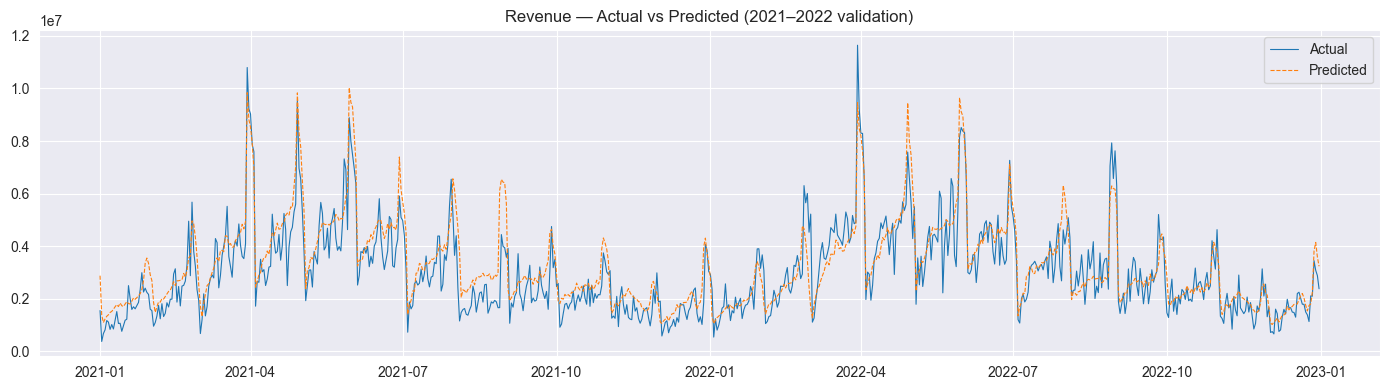

In [13]:
val = train[train['year'].isin([2021, 2022])].copy()
val = val.drop(columns=['rev_norm', 'cogs_norm'], errors='ignore')
val = val.merge(seasonal, on=['month', 'day'], how='left')
val['rev_norm']  = val['rev_norm'].fillna(1.0)
val['cogs_norm'] = val['cogs_norm'].fillna(1.0)
val['years_ahead'] = val['year'] - 2022  # negative for historical
val['Revenue_pred'] = base_rev  * growth_rev**val['years_ahead']  * val['rev_norm']
val['COGS_pred']    = base_cogs * growth_cogs**val['years_ahead'] * val['cogs_norm']

def mape(actual, pred):
    return (np.abs(actual - pred) / actual).mean() * 100

print(f'MAPE Revenue (2021–2022): {mape(val["Revenue"], val["Revenue_pred"]):.2f}%')
print(f'MAPE COGS    (2021–2022): {mape(val["COGS"],    val["COGS_pred"]):.2f}%')

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(val['Date'], val['Revenue'],      lw=0.8, label='Actual')
ax.plot(val['Date'], val['Revenue_pred'], lw=0.8, linestyle='--', label='Predicted')
ax.set_title('Revenue — Actual vs Predicted (2021–2022 validation)')
ax.legend(); plt.tight_layout(); plt.show()

## 7 — Export Submission

In [14]:
submission = test[['Date', 'Revenue_pred', 'COGS_pred']].rename(
    columns={'Revenue_pred': 'Revenue', 'COGS_pred': 'COGS'}
)
submission['Date'] = submission['Date'].dt.strftime('%Y-%m-%d')
submission.to_csv(OUT_FILE, index=False)

print(f'Saved {len(submission)} rows to {OUT_FILE}')
submission.head(10)

Saved 548 rows to ../data/raw/submission.csv


,Date,Revenue,COGS
0,2023-01-01,2665507.20,2518885.15
1,2023-01-02,1280007.89,1136463.00
2,2023-01-03,1015899.51,822721.12
3,2023-01-04,1142997.27,914554.18
4,2023-01-05,1236312.34,984390.24
5,2023-01-06,1289094.55,1040418.44
6,2023-01-07,1370539.45,1119430.49
7,2023-01-08,1409121.71,1142951.32
8,2023-01-09,1483990.79,1221315.20
9,2023-01-10,1570643.46,1258681.76


In [21]:
import numpy as np
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import lightgbm as lgb
import xgboost as xgb
from sklearn.dummy import DummyRegressor

# =========================================================
# 1. CHUẨN BỊ VÀ CHIA DỮ LIỆU (Khắc phục lỗi NameError)
# =========================================================
# Định nghĩa đặc trưng đầu vào và mục tiêu dự báo
features = ['year', 'month', 'day', 'day_of_year']
target = 'Revenue'

# Chia tập dữ liệu theo thời gian:
# Train: Từ đầu đến hết năm 2021
# Validation: Năm 2022 (Năm hoàn chỉnh gần nhất để test)
train_data = train[train['year'] < 2022].copy()
val_data   = train[train['year'] == 2022].copy()

# Khởi tạo X và y
X_train, y_train = train_data[features], train_data[target]
X_val, y_val     = val_data[features], val_data[target]

# Hàm đánh giá và in kết quả định dạng bảng
def evaluate_and_print(model_name, y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)
    print(f"| {model_name:<25} | {mae:<10,.2f} | {rmse:<10,.2f} | {r2:<7.4f} |")

print("=== KẾT QUẢ SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH ===")
print(f"| {'Mô hình (Model)':<25} | {'MAE':<10} | {'RMSE':<10} | {'R^2':<7} |")
print("-" * 63)

# ---------------------------------------------------------
# 1. MÔ HÌNH BASELINE (Cơ sở)
# Sử dụng DummyRegressor (Dự báo bằng giá trị trung bình của tập Train)
# Đây là mốc cơ bản nhất để chứng minh ML có thực sự hiệu quả hay không.
# ---------------------------------------------------------
baseline_model = DummyRegressor(strategy='mean')
baseline_model.fit(X_train, y_train)
baseline_preds = baseline_model.predict(X_val)
evaluate_and_print("Baseline (Mean)", y_val, baseline_preds)

# ---------------------------------------------------------
# 2. MÔ HÌNH XGBOOST
# ---------------------------------------------------------
xgb_model = xgb.XGBRegressor(random_state=42, n_estimators=100)
xgb_model.fit(X_train, y_train)
xgb_preds = xgb_model.predict(X_val)
evaluate_and_print("XGBoost", y_val, xgb_preds)

# ---------------------------------------------------------
# 3. MÔ HÌNH LIGHTGBM (Mô hình chủ lực của nhóm)
# ---------------------------------------------------------
lgb_model = lgb.LGBMRegressor(random_state=42, n_estimators=100)
lgb_model.fit(X_train, y_train)
lgb_preds = lgb_model.predict(X_val)
evaluate_and_print("LightGBM", y_val, lgb_preds)

=== KẾT QUẢ SO SÁNH HIỆU SUẤT CÁC MÔ HÌNH ===
| Mô hình (Model)           | MAE        | RMSE       | R^2     |
---------------------------------------------------------------
| Baseline (Mean)           | 1,746,066.86 | 2,056,992.14 | -0.5103 |
| XGBoost                   | 723,083.88 | 1,025,341.17 | 0.6247  |
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001064 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 311
[LightGBM] [Info] Number of data points in the train set: 3468, number of used features: 4
[LightGBM] [Info] Start training from score 4400440.527528
| LightGBM                  | 655,359.77 | 920,826.48 | 0.6973  |
